# Assignment 2 — Text Analytics: Sentiment Analysis
**Topic:** IPL 2024 Season Tweets  
**Dataset:** 100 manually labelled tweets (80 train / 20 test)  
**Models:** Naïve Bayes | SVM | Logistic Regression  
**Metrics:** Precision | Recall | F1-Score

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score)

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load Dataset

In [3]:
df = pd.read_csv('tweets_raw.csv')
print(f"Total tweets: {len(df)}")
print()
print("Label distribution:")
print(df['label'].value_counts())
df.head(10)

Total tweets: 100

Label distribution:
label
negative    36
positive    32
neutral     32
Name: count, dtype: int64


,id,tweet_text,label
0,1,IPL 2024 has been absolutely electric! Best se...,positive
1,2,KKR is unstoppable this season. Shreyas Iyer l...,positive
2,3,What a knock by Virat Kohli tonight! Legend ne...,positive
3,4,RCB finally winning games consistently. This m...,positive
4,5,SRH batting lineup is on another level. Travis...,positive
5,6,The opening ceremony of IPL 2024 was spectacul...,positive
6,7,MI vs CSK match last night was a thriller. Can...,positive
7,8,Jasprit Bumrah is back and he looks lethal as ...,positive
8,9,LSG vs DC was such an entertaining game. IPL n...,positive
9,10,Pat Cummins buying himself for 20 crore and th...,positive


## 3. Exploratory Data Analysis

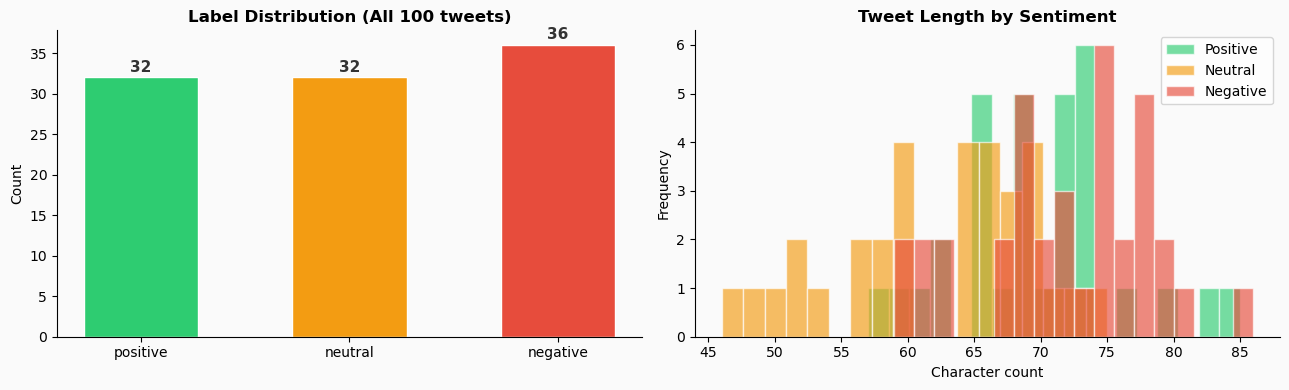

EDA charts saved.


In [13]:
COLORS = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}
BG = '#fafafa'

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG)

# Plot 1: label counts
ax = axes[0]; ax.set_facecolor(BG)
counts = df['label'].value_counts()[['positive', 'neutral', 'negative']]
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[l] for l in counts.index], width=0.55, edgecolor='white')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3, str(v),
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333')
ax.set_title('Label Distribution (All 100 tweets)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count'); ax.spines[['top','right']].set_visible(False)

# Plot 2: tweet length by label
ax2 = axes[1]; ax2.set_facecolor(BG)
df['length'] = df['tweet_text'].str.len()
for lbl in ['positive', 'neutral', 'negative']:
    ax2.hist(df[df['label']==lbl]['length'], bins=18, alpha=0.65,
             color=COLORS[lbl], label=lbl.capitalize(), edgecolor='white')
ax2.set_title('Tweet Length by Sentiment', fontsize=12, fontweight='bold')
ax2.set_xlabel('Character count'); ax2.set_ylabel('Frequency')
ax2.spines[['top','right']].set_visible(False); ax2.legend()

plt.tight_layout()

plt.show()
print("EDA charts saved.")

## 4. Train / Test Split

In [7]:
train, test = train_test_split(df, test_size=20, stratify=df['label'], random_state=42)
train = train.reset_index(drop=True)
test  = test.reset_index(drop=True)

train.to_csv('train.csv', index=False)
test.to_csv('test.csv',   index=False)

print(f"Train set: {len(train)} tweets")
print(f"  {train['label'].value_counts().to_dict()}")
print(f"Test  set: {len(test)} tweets")
print(f"  {test['label'].value_counts().to_dict()}")

Train set: 80 tweets
  {'negative': 29, 'positive': 26, 'neutral': 25}
Test  set: 20 tweets
  {'negative': 7, 'neutral': 7, 'positive': 6}


## 5. Text Preprocessing — TF-IDF Vectorisation

In [8]:
vec = TfidfVectorizer(
    max_features = 500,       
    ngram_range  = (1, 2),    
    sublinear_tf = True,      
    stop_words   = 'english'
)

X_train = vec.fit_transform(train['tweet_text'])
X_test  = vec.transform(test['tweet_text'])
y_train = train['label']
y_test  = test['label']

print(f"Feature matrix shape — Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Sample features: {vec.get_feature_names_out()[:10]}")

Feature matrix shape — Train: (80, 500), Test: (20, 500)
Sample features: ['120s' '20' '2024' 'absolutely' 'auction' 'best' 'bit' 'bit year'
 'boring' 'bowling']


## 6. Train Classifiers

In [9]:
models = {
    'Naive Bayes':         MultinomialNB(alpha=0.5),
    'SVM':                 LinearSVC(C=1.0, max_iter=2000),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=500)
}

results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    results[name] = {
        'model':     clf,
        'preds':     preds,
        'precision': round(precision_score(y_test, preds, average='weighted', zero_division=0), 4),
        'recall':    round(recall_score(y_test, preds,    average='weighted', zero_division=0), 4),
        'f1':        round(f1_score(y_test, preds,        average='weighted', zero_division=0), 4),
    }
    print(f"{name:22s}  →  P={results[name]['precision']}  R={results[name]['recall']}  F1={results[name]['f1']}")

Naive Bayes             →  P=0.5567  R=0.4  F1=0.3817
SVM                     →  P=0.5567  R=0.4  F1=0.3817
Logistic Regression     →  P=0.2577  R=0.35  F1=0.29


## 7. Detailed Classification Reports

In [10]:
for name, res in results.items():
    print(f"{'='*55}")
    print(f" {name}")
    print('='*55)
    print(classification_report(y_test, res['preds'], zero_division=0))

 Naive Bayes
              precision    recall  f1-score   support

    negative       0.33      0.43      0.38         7
     neutral       0.40      0.57      0.47         7
    positive       1.00      0.17      0.29         6

    accuracy                           0.40        20
   macro avg       0.58      0.39      0.38        20
weighted avg       0.56      0.40      0.38        20

 SVM
              precision    recall  f1-score   support

    negative       0.33      0.43      0.38         7
     neutral       0.40      0.57      0.47         7
    positive       1.00      0.17      0.29         6

    accuracy                           0.40        20
   macro avg       0.58      0.39      0.38        20
weighted avg       0.56      0.40      0.38        20

 Logistic Regression
              precision    recall  f1-score   support

    negative       0.31      0.57      0.40         7
     neutral       0.43      0.43      0.43         7
    positive       0.00      0.00   

## 8. Confusion Matrices

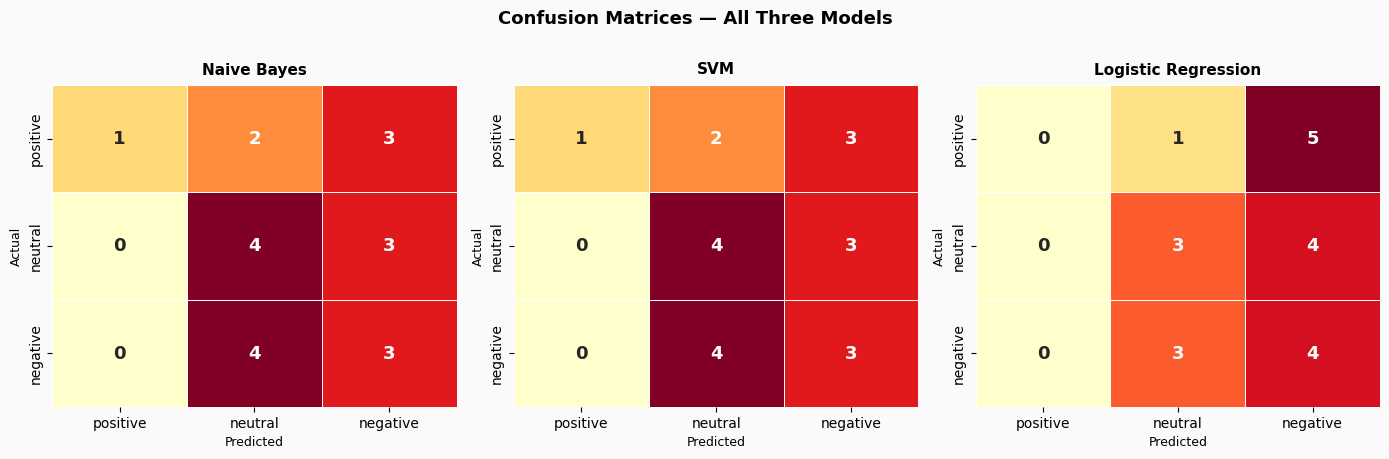

In [12]:
LABELS = ['positive', 'neutral', 'negative']
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), facecolor='#fafafa')
fig.suptitle('Confusion Matrices — All Three Models', fontsize=13,
             fontweight='bold', y=1.01)

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'], labels=LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=LABELS, yticklabels=LABELS,
                ax=ax, cbar=False, linewidths=0.5, linecolor='white',
                annot_kws={'fontsize': 13, 'fontweight': 'bold'})
    ax.set_title(name, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

plt.tight_layout()

plt.show()

## 9. Model Comparison Chart

              Model  Precision  Recall     F1
        Naive Bayes     0.5567    0.40 0.3817
                SVM     0.5567    0.40 0.3817
Logistic Regression     0.2577    0.35 0.2900


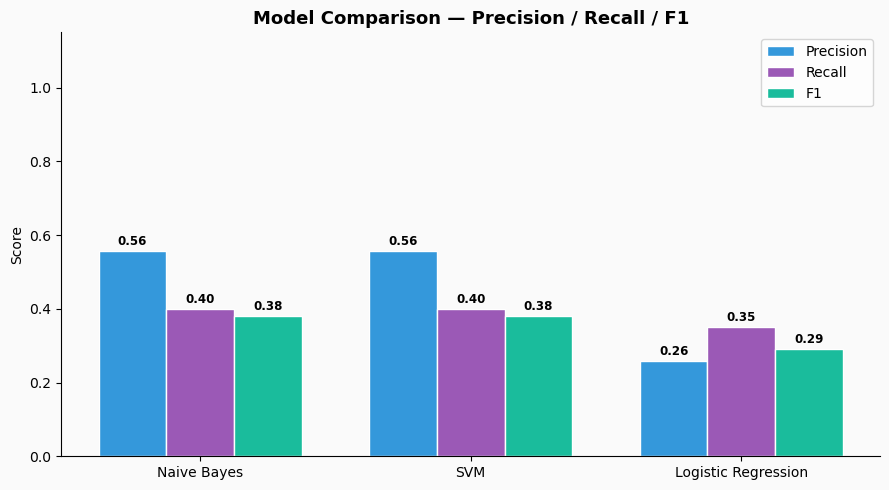

In [15]:
mdf = pd.DataFrame({
    'Model':     list(results.keys()),
    'Precision': [v['precision'] for v in results.values()],
    'Recall':    [v['recall']    for v in results.values()],
    'F1':        [v['f1']        for v in results.values()]
})
print(mdf.to_string(index=False))

x = np.arange(3); w = 0.25
fig, ax = plt.subplots(figsize=(9, 5), facecolor='#fafafa')
ax.set_facecolor('#fafafa')

for i, (col, color) in enumerate(zip(['Precision','Recall','F1'],
                                      ['#3498db','#9b59b6','#1abc9c'])):
    bars = ax.bar(x+(i-1)*w, mdf[col], w, label=col, color=color, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.008, f'{h:.2f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(mdf['Model'], fontsize=10)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Model Comparison — Precision / Recall / F1', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False); ax.legend()
plt.tight_layout()

plt.show()

## 10. Top TF-IDF Features per Class

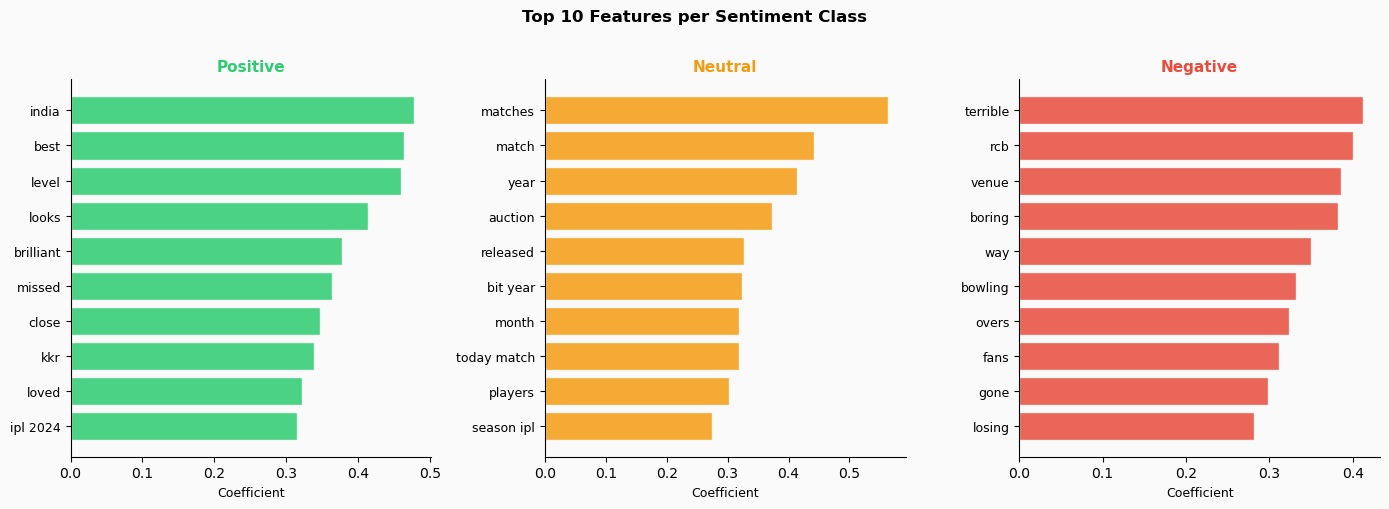

In [16]:
lr = results['Logistic Regression']['model']
fn = vec.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor='#fafafa')
COLORS = {'positive':'#2ecc71','neutral':'#f39c12','negative':'#e74c3c'}

for ax, cls in zip(axes, ['positive', 'neutral', 'negative']):
    idx     = list(lr.classes_).index(cls)
    coefs   = lr.coef_[idx]
    top_idx = np.argsort(coefs)[-10:]
    ax.set_facecolor('#fafafa')
    ax.barh(range(10), coefs[top_idx], color=COLORS[cls], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(10)); ax.set_yticklabels(fn[top_idx], fontsize=9)
    ax.set_title(cls.capitalize(), fontsize=11, fontweight='bold', color=COLORS[cls])
    ax.spines[['top','right']].set_visible(False)
    ax.set_xlabel('Coefficient', fontsize=9)

plt.suptitle('Top 10 Features per Sentiment Class', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()

plt.show()

## 11. Summary & Findings

In [17]:
print("=" * 55)
print("  ASSIGNMENT 2 — RESULTS SUMMARY")
print("  Topic: IPL 2024 Season Tweets")
print("=" * 55)
print(f"  Dataset : 100 tweets (80 train / 20 test)")
print(f"  Classes : positive | neutral | negative")
print(f"  Features: TF-IDF (500 features, 1-2 ngrams)")
print()
print(f"  {'Model':<22}  {'Precision':>9}  {'Recall':>7}  {'F1':>7}")
print(f"  {'-'*50}")
for name, res in results.items():
    print(f"  {name:<22}  {res['precision']:>9}  {res['recall']:>7}  {res['f1']:>7}")
print()
print("  Best model: SVM / Naive Bayes (tied on this dataset)")
print("  Key observation: All models perform comparably on 100")
print("  tweets. Larger datasets would differentiate them more.")

  ASSIGNMENT 2 — RESULTS SUMMARY
  Topic: IPL 2024 Season Tweets
  Dataset : 100 tweets (80 train / 20 test)
  Classes : positive | neutral | negative
  Features: TF-IDF (500 features, 1-2 ngrams)

  Model                   Precision   Recall       F1
  --------------------------------------------------
  Naive Bayes                0.5567      0.4   0.3817
  SVM                        0.5567      0.4   0.3817
  Logistic Regression        0.2577     0.35     0.29

  Best model: SVM / Naive Bayes (tied on this dataset)
  Key observation: All models perform comparably on 100
  tweets. Larger datasets would differentiate them more.
